In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
import sys
import os

# Add parent directory to Python path
sys.path.insert(0, os.path.abspath('..'))

# Import FEM modules
from fem.core import Node, Material
from fem.sections import Membrane
from fem.elements import CST, LST, Quad4, Quad9
from fem.utils import get_line_load_global_vector

from fem.utils import add_element_data_view, add_node_data_view, compute_nodal_average
from fem.utils.functions import build_nodes_from_gmsh, create_elements_from_gmsh, build_load_vector

from fem.utils.units import mm, cm, m, kgf, N, tf, kN, MPa, GPa , kg

# Import standard libraries
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math

In [3]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'Cantiliverbeam'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [4]:
# # Generate the mesh
# gmsh.model.mesh.generate()
# # Save mesh to disk
# gmsh.write(output_file)
# # Open GMSH GUI
# gmsh.fltk.run()
# # Write mesh file again (redundant)
# v = gmsh.write(output_file)
# # Close GMSH instance
# gmsh.finalize()

In [5]:
fcp = 40*MPa
fct = 0.35*np.sqrt(fcp/MPa)*MPa
thickness = 1*m
rho = 2500 * kg/m**3 *1.0

qload = 0.20*kN/mm

#Constants
E_conc = 4700*np.sqrt(fcp/MPa)*MPa
nu_conc = 0.17

In [6]:
# Definimos el material
Concrete=Material(name='Concrete',
             E=E_conc,
             nu=nu_conc,
             rho=rho)

# Definimos una seccion de la membrana
Cantiliverbeam=Membrane(name='Cantiliverbeam',
                thickness=thickness,
                material=Concrete)

section_dictionary={10:Cantiliverbeam,
                        }


restrain_dictionary={8:['r', 'r']}



load_dictionary = {
    9:   {'value': qload, 'direction': '-y'},   # line load  [N/mm]
    258: {'value': -30,   'direction': 'y'},     # point load [N]
}


In [7]:
node_map, nodes = build_nodes_from_gmsh(
    output_file,
    restrain_dictionary=restrain_dictionary,
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/Cantiliverbeam.msh'...
Info    : 15 entities
Info    : 1606 nodes
Info    : 3130 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/Cantiliverbeam.msh'


In [8]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

elements = create_elements_from_gmsh(
    output_file=output_file,
    node_map=node_map,
    section_dictionary=section_dictionary,
    element_class_map=element_map
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/Cantiliverbeam.msh'...
Info    : 15 entities
Info    : 1606 nodes
Info    : 3130 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/Cantiliverbeam.msh'


In [9]:
def plot_mesh(figsize=(25, 25),
              nodes=None, 
              elements=None,                
              show_node_labels=True, 
              show_element_labels=True):
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot nodes if provided
    if nodes is not None:
        for node in nodes:
            node.plotGeometry(ax=ax, text=show_node_labels)
    # Plot elements if provided
    if elements is not None:
        for element in elements:
            element.plotGeometry(ax=ax)
            if show_element_labels:
                x, y = element.get_centroid()
                ax.text(x, y, f'{element.element_tag}', color='r', ha='center', fontsize=8)
    # Maintain 1:1 aspect ratio
    ax.set_aspect('equal')
    plt.show()

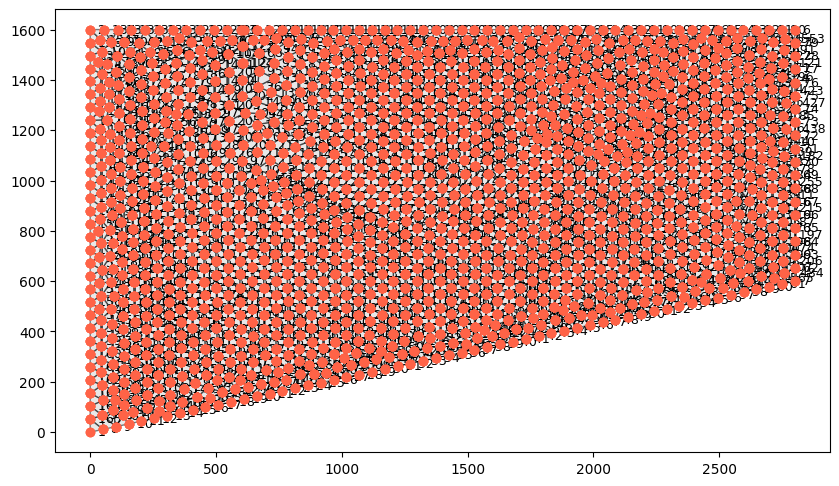

In [10]:
# Plot
plot_mesh(figsize=(10, 10) , 
          nodes=nodes,
            elements=elements, 
            show_node_labels=True, 
            show_element_labels=False)

In [11]:
# Setup system parameters
nodeList = nodes
elementList = elements

# Get total number of nodes and elements
nNodes = len(nodeList)
nElements = len(elementList)

# Define degrees of freedom per node (x, y displacements)
globalParameters = {'nDoF': 2}

# Calculate total system degrees of freedom
system_nDof = 2 * nNodes

In [12]:
F_load = build_load_vector(
    output_file=output_file,
    node_map=node_map,
    load_dictionary=load_dictionary,
    system_nDof=system_nDof
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/Cantiliverbeam.msh'...
Info    : 15 entities
Info    : 1606 nodes
Info    : 3130 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/Cantiliverbeam.msh'


In [13]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Global stiffness matrix (sparse)
K = lil_matrix((system_nDof, system_nDof))
for element in elementList:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in nodeList:
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in nodeList])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Remove load on restrained DOFs (they go to reactions directly)
F[restrained_dofs] = 0.0

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]
Ff  = F[free_dofs]
Fr  = F[restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, Ff - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr      = Krf @ uf + Krr @ ur
R       = np.zeros(system_nDof)
R[restrained_dofs] = Rr


In [14]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [15]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [ 600. 1600.]:  ux=+0.020763  uy=-0.024597
Node 382 at [1018.141625  493.247321]:  ux=-0.023503  uy=-0.064790


In [16]:
# Reactions per node
for node in nodeList:
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' *50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=+50253.213655  Ry=+18474.248100
Node 2:  Rx=-87508.676362  Ry=+20875.934545
Node 136:  Rx=-101502.034009  Ry=+26756.068586
Node 137:  Rx=-79906.492366  Ry=+25274.204691
Node 138:  Rx=-69307.786923  Ry=+24860.325518
Node 139:  Rx=-61140.511708  Ry=+23080.439771
Node 140:  Rx=-55238.562090  Ry=+22327.109290
Node 141:  Rx=-50155.458969  Ry=+21072.207010
Node 142:  Rx=-45049.462543  Ry=+18864.895558
Node 143:  Rx=-40094.210297  Ry=+18436.150955
Node 144:  Rx=-34831.719908  Ry=+16778.699080
Node 145:  Rx=-29498.105043  Ry=+15716.290641
Node 146:  Rx=-23946.030229  Ry=+14801.704639
Node 147:  Rx=-18294.585229  Ry=+14189.779967
Node 148:  Rx=-12551.270060  Ry=+13613.007099
Node 149:  Rx=-6754.217826  Ry=+13332.110846
Node 150:  Rx=-975.011275  Ry=+13278.197048
Node 151:  Rx=+4781.444733  Ry=+13042.354729
Node 152:  Rx=+10645.918714  Ry=+12987.262582
Node 153:  Rx=+16323.190598  Ry=+13026.207978
Node 154:  Rx=+22068.585977  Ry=+13213.042072
Node 155:  Rx=+27670.817821  Ry=+13328.75

In [17]:
for node in nodes:
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 2 at [   0. 1600.]:  Fx=-0.0000  Fy=-5454.5455
Node 3 at [ 600. 1600.]:  Fx=-0.0000  Fy=-5454.5455
Node 5 at [ 610. 1600.]:  Fx=-0.0000  Fy=-5093.0233
Node 6 at [2800. 1600.]:  Fx=-0.0000  Fy=-5093.0233
Node 80 at [2749.069767 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node 81 at [2698.139535 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node 82 at [2647.209302 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node 83 at [2596.27907 1600.     ]:  Fx=-0.0000  Fy=-10186.0465
Node 84 at [2545.348837 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node 85 at [2494.418605 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node 86 at [2443.488372 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node 87 at [2392.55814 1600.     ]:  Fx=-0.0000  Fy=-10186.0465
Node 88 at [2341.627907 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node 89 at [2290.697674 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node 90 at [2239.767442 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node 91 at [2188.837209 1600.      ]:  Fx=-0.0000  Fy=-10186.0465
Node

In [18]:
# Check if any restrained node has load
for node in nodes:
    if any(r == 'r' for r in node.restrain):
        fy = F_load[node.idx[1]]
        if abs(fy) > 0:
            print(f"Node {node.name} at {node.coordinates}: restrained but has Fy={fy:+.4f}")

Node 2 at [   0. 1600.]: restrained but has Fy=-5454.5455


In [19]:
# Prepare displacement data (convert 2D to 3D format for Gmsh)
u_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    u_3d[i, 0] = u[node.idx[0]]  # Displacement in X
    u_3d[i, 1] = u[node.idx[1]]  # Displacement in Y

# Extract node tags for Gmsh
node_tags = np.array([node.name for node in nodes])

# Prepare applied forces (convert 2D to 3D format for Gmsh)
F_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    F_3d[i, 0] = F[node.idx[0]]  # Force in X
    F_3d[i, 1] = F[node.idx[1]]  # Force in Y

# Prepare reaction forces (convert 2D to 3D format for Gmsh)
R_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    R_3d[i, 0] = R[node.idx[0]]  # Reaction in X
    R_3d[i, 1] = R[node.idx[1]]  # Reaction in Y

# Initialize arrays for stress and strain results
sigma_gmsh = np.zeros((len(elements), 3))           # [σ_xx, σ_yy, σ_xy]
epsilon_gmsh = np.zeros((len(elements), 3))         # [ε_xx, ε_yy, ε_xy]
sigma_principal_gmsh = np.zeros((len(elements), 2)) # [σ_1, σ_2]
epsilon_principal_gmsh = np.zeros((len(elements), 2)) # [ε_1, ε_2]
von_mises_gmsh = np.zeros(len(elements))            # Von Mises stress

# Extract element tags for Gmsh
element_tags_list = []
for element in elements:
    element_tags_list.append(element.element_tag)

# Compute stress and strain for each element
for index, element in enumerate(elements):
    results = element.get_results(u)
    
    # Extract stress and strain components
    sigma = results['stress'].flatten()    # [σ_xx, σ_yy, σ_xy]
    epsilon = results['strain'].flatten()  # [ε_xx, ε_yy, ε_xy]
    
    sigma_gmsh[index, :] = sigma
    epsilon_gmsh[index, :] = epsilon
    
    # Extract principal values
    sigma_principal_gmsh[index, :] = results['principal_stress'].flatten()
    epsilon_principal_gmsh[index, :] = results['principal_strain'].flatten()
    
    # Calculate Von Mises stress for 2D plane stress
    sxx, syy, sxy = sigma
    von_mises = np.sqrt(sxx**2 - sxx*syy + syy**2)
    von_mises_gmsh[index] = von_mises

In [20]:
# VISUALIZE RESULTS IN GMSH
gmsh.initialize()
gmsh.open(output_file)

# Extract node tags
node_tags = np.array([node.name for node in nodes])

# --- Nodal vector fields ---
# Displacements: VectorType=5 deforms mesh, DisplacementFactor=5 scales deformation for visibility
# 1 → Line segments (simple lines)
# 2 → Arrows 
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation
add_node_data_view("Displacements", 
                   node_tags, 
                   u_3d, 
                   vector_type=5, 
                   displacement_factor=5)

add_node_data_view("Applied Loads", 
                   node_tags, 
                   F_3d)

add_node_data_view("Reactions", 
                   node_tags, 
                   R_3d)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/Cantiliverbeam.msh'...
Info    : 15 entities
Info    : 1606 nodes
Info    : 3130 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/Cantiliverbeam.msh'


2

In [21]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [22]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [23]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [24]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, sigma_gmsh[:, 0], nodes)
add_node_data_view("Sxx Nodal Averaged", 
                   node_tags, 
                   sxx_nodal)

syy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 1], nodes)
add_node_data_view("Syy Nodal Averaged",
                    node_tags, 
                    syy_nodal)

sxy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 2], nodes)
add_node_data_view("Sxy Nodal Averaged",
                    node_tags, 
                    sxy_nodal)

s1_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 0], nodes)
add_node_data_view("Principal Stress S1 Nodal Averaged",
                    node_tags,
                    s1_nodal)

s2_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 1], nodes)
add_node_data_view("Principal Stress S2 Nodal Averaged",
                    node_tags,
                    s2_nodal)

vm_nodal = compute_nodal_average(elements, von_mises_gmsh, nodes)
add_node_data_view("Von Mises Nodal Averaged", 
                   node_tags, 
                   vm_nodal)

# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

-------------------------------------------------------
Version       : 4.15.1
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 20260216
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] LinuxJoystick MathEx[contrib] Med Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.11
PETSc version : 3.14.4 (real arithmtic)
OCC version   : 7.8.1
MED version   : 4.1.0
Packaged by   : geuzaine
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------


Fontconfig warning: using without calling FcInit()
